# 13 — The complete national model: Great Britain, all out

The most complete national transport model of Great Britain this course can
build from open data. **Model size: 194,874 links (~94,000 km) over four road
classes (motorway, trunk, primary and secondary), ~129,000 trigger-built
nodes, and a complete zone system of 350 local-authority districts covering
67.4M residents — carrying 1.35 million peak-hour trips.** On top of it, the
full run of things a transport model can compute and put on a map — zone
choropleths, accessibility, desire lines, equilibrium flows, congestion,
select-link analysis, corridor rankings and national screenlines.

Every model assumption lives in the **PARAMS** cell below — change a number,
re-run, and the whole model follows.

| file | contents | source |
|---|---|---|
| `uk_roads_dense.geojson.gz` | GB motorways + trunk + primary + secondary roads, topologically noded | © OpenStreetMap contributors (ODbL), Overpass API |
| `gb_lad_zones.geojson.gz` | 350 local-authority districts with boundaries and population | ONS Open Geography (OGL) + NOMIS mid-year estimates (OGL) |
| `gb_boundary.geojson` | GB outline for the maps | public-domain world boundaries |

Nothing is downloaded at run time. The full model builds and runs in roughly
five to ten minutes.

## PARAMS — every model assumption in one place

In [41]:
PARAMS = {
    # free-flow speed (km/h) and capacity (veh/h/direction) per link class
    "network": {
        "motorway":  {"speed": 105, "capacity": 4000},
        "trunk":     {"speed": 75,  "capacity": 1800},
        "primary":   {"speed": 60,  "capacity": 1200},
        "secondary": {"speed": 48,  "capacity": 900},
        "ramp":      {"speed": 55,  "capacity": 1500},
    },
    # how each zone is tied into the network
    "connectors": {
        "base": 2, "per_100k_residents": 0.8, "max": 6,
        "min_separation_deg": 0.02, "speed": 40, "capacity": 10000,
    },
    # gravity demand
    "demand": {
        "trip_rate": 0.02,          # inter-district car trips per resident in the peak hour
        "deterrence_beta": 0.05,    # 1/min - steeper than a strategic model: commuting dominates
        "attraction_power": 0.9,    # sublinear population proxy for attractions
    },
    # equilibrium assignment
    "assignment": {
        "algorithm": "bfw", "max_iter": 30, "rgap": 1e-3,
        "vdf_alpha": 0.15, "vdf_beta": 4.0,
    },
    # analysis & display
    "analysis": {
        "select_link_near": (52.48, -1.89),   # M6 at Birmingham
        "desire_lines_top_n": 300,
        "flow_display_min": 150,              # veh/h below which links are not drawn
        "screenlines": {
            "England-Scotland border": [(-3.6, 54.98), (-1.8, 55.82)],
            "England-Wales border":    [(-3.15, 53.35), (-2.62, 51.58)],
        },
    },
}

In [42]:
import gzip
import json
import time
import warnings
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import LineString, shape

warnings.filterwarnings("ignore")

DATA = Path("data")
with gzip.open(DATA / "uk_roads_dense.geojson.gz", "rt", encoding="utf-8") as fh:
    roads_gj = json.load(fh)
with gzip.open(DATA / "gb_lad_zones.geojson.gz", "rt", encoding="utf-8") as fh:
    zones_gj = json.load(fh)
boundary = gpd.GeoDataFrame(geometry=[shape(f["geometry"]) for f in json.load(open(DATA / "gb_boundary.geojson"))["features"]], crs=4326)

roads = gpd.GeoDataFrame(
    [{"cls": f["properties"]["class"], "ref": f["properties"]["ref"]} for f in roads_gj["features"]],
    geometry=[shape(f["geometry"]) for f in roads_gj["features"]], crs=4326)
zones = gpd.GeoDataFrame(
    [f["properties"] for f in zones_gj["features"]],
    geometry=[shape(f["geometry"]) for f in zones_gj["features"]], crs=4326)
zones["centroid"] = zones.geometry.representative_point()
zones["area_km2"] = zones.to_crs(27700).area / 1e6
zones["density"] = (zones.population / zones.area_km2).round(0)

km_by_cls = (roads.assign(km=roads.to_crs(27700).length / 1000).groupby("cls").km.sum().round(0))
print(f"network: {len(roads):,} links / {km_by_cls.sum():,.0f} km   "
      f"zones: {len(zones)} districts / {zones.population.sum() / 1e6:.1f}M residents")
km_by_cls.astype(int)

Task was destroyed but it is pending!
task: <Task pending name='Task-1539' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Riz\Desktop\AequilibraE\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-1540' coro=<Kernel.shell_main() running at C:\Users\Riz\Desktop\AequilibraE\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Riz\Desktop\AequilibraE\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
Task was destroyed but it is pending!
task: <Task pending name='Task-1540' coro=<Kernel.shell_main() running at C:\Users\Riz\Desktop\AequilibraE\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


network: 194,874 links / 94,409 km   zones: 350 districts / 67.4M residents


cls
motorway      7078
primary      27557
ramp          3671
secondary    29240
trunk        26863
Name: km, dtype: int64

In [43]:
# JupyterGIS map helper ------------------------------------------------------
# GISDocument is JupyterGIS' notebook API: it builds a live, QGIS-like map
# document rendered directly in JupyterLab. Layers added from GeoDataFrames
# are converted to GeoJSON on the fly.
#
# add_gdf also translates the declarative symbology into the OpenLayers
# flat-style expressions the current JupyterGIS frontend renders from, so
# colours and line widths show up without touching the symbology panel.
import json

import matplotlib.colors
import matplotlib.pyplot as _plt
from jupytergis import GISDocument
from jupytergis_lab.notebook.symbology import to_symbology_state

OSM_TILES = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"

def new_map(gdf_for_extent=None, zoom=12):
    """Create a GISDocument centred on a layer, with an OpenStreetMap basemap."""
    kwargs = {}
    if gdf_for_extent is not None:
        b = gdf_for_extent.total_bounds  # (minx, miny, maxx, maxy)
        kwargs = {"longitude": (b[0] + b[2]) / 2, "latitude": (b[1] + b[3]) / 2, "zoom": zoom}
    doc = GISDocument(**kwargs)
    doc.add_raster_layer(OSM_TILES, name="OpenStreetMap", attribution="(C) OpenStreetMap contributors", opacity=0.6)
    return doc

def _hex(rgba):
    return matplotlib.colors.to_hex(rgba)

def _ramp_expr(fld, params):
    name, dom = params.get("name", "viridis"), params.get("domain") or [0.0, 1.0]
    cmap = _plt.get_cmap(name)
    if params.get("reverse"):
        cmap = cmap.reversed()
    expr = ["interpolate", ["linear"], ["get", fld]]
    for i in range(7):
        t = i / 6
        expr += [dom[0] + t * (dom[1] - dom[0]), _hex(cmap(t))]
    return expr

def _scalar_expr(fld, params):
    d, r = params["domain"], params["range"]
    return ["interpolate", ["linear"], ["get", fld], d[0], r[0], d[1], r[1]]

def _cat_expr(fld, params, gdf):
    cmap = _plt.get_cmap(params.get("colorRamp", "tab10"))
    vals = list(dict.fromkeys(gdf[fld].dropna()))
    expr = ["match", ["get", fld]]
    for i, v in enumerate(vals):
        expr += [v, _hex(cmap(i % cmap.N))]
    return expr + ["#9ca3af"]

def _flat_style(symbology, gdf):
    """Grammar symbology -> OpenLayers flat-style dict (what the map renders)."""
    state = to_symbology_state(symbology)
    if not state:
        return None
    flat = {}
    for layer in state.get("layers", []):
        for rule in layer.get("rules", []):
            flds = rule.get("fields") or [None]
            for m in rule.get("mappings", []):
                scheme = m["scale"]["scheme"]
                params = m["scale"].get("params", {})
                if scheme == "constant_rgba":
                    val = params["value"]
                    val = _hex([c if c <= 1 else c / 255 for c in val]) if isinstance(val, (list, tuple)) else val
                elif scheme == "constant_num":
                    val = params["value"]
                elif scheme == "colorMap":
                    val = _ramp_expr(flds[0], params)
                elif scheme == "scalar":
                    val = _scalar_expr(flds[0], params)
                elif scheme == "categorical":
                    val = _cat_expr(flds[0], params, gdf)
                else:
                    continue
                for enc in m.get("encodings", []):
                    flat[enc] = val
    if any(k.startswith("circle") for k in flat) and "circle-radius" not in flat:
        flat["circle-radius"] = 5
    if "stroke-color" in flat and "stroke-width" not in flat:
        flat["stroke-width"] = 1.5
    return flat or None

def merge_lines(gdf, tol=0.01):
    """Collapse many lines into a single MultiLineString feature.

    Backdrop and class-display layers do not need per-feature identity, and one
    merged feature is a fraction of the size of tens of thousands of features -
    which keeps national-scale layers inside the notebook sync message limit.
    """
    import geopandas as _gpd
    from shapely.geometry import MultiLineString
    parts = []
    for geom in gdf.geometry.simplify(tol):
        if geom is None or geom.is_empty:
            continue
        parts.extend(geom.geoms if geom.geom_type == "MultiLineString" else [geom])
    return _gpd.GeoDataFrame({"links": [len(parts)]}, geometry=[MultiLineString(parts)], crs=gdf.crs)

def _round_coords(o, nd=5):
    if isinstance(o, (int, float)):
        return round(o, nd)
    if isinstance(o, list):
        return [_round_coords(v, nd) for v in o]
    return o

def add_gdf(doc, gdf, name, symbology=None, **kwargs):
    """Add a GeoDataFrame to the map as a GeoJSON layer, with rendered symbology.

    Coordinates are quantized to ~1 m so even national-scale layers stay well
    under Jupyter's websocket message limit (oversized layers are dropped
    silently by the sync, so this matters more than it looks).
    """
    data = json.loads(gdf.to_json())
    for f in data.get("features", []):
        g = f.get("geometry")
        if g and "coordinates" in g:
            g["coordinates"] = _round_coords(g["coordinates"])
    lid = doc.add_geojson_layer(data=data, name=name,
                                symbology=symbology, **kwargs)
    flat = _flat_style(symbology, gdf)
    if flat:
        layer = doc._layers.get(lid)
        layer["parameters"]["color"] = flat
        doc._layers[lid] = layer
    return lid

## The zone system

Every local-authority district in Great Britain, coloured by population
density — the first thing any model report shows.

In [44]:
from jupytergis_lab.notebook.symbology import constant, field

zones["log_density"] = np.log10(zones.density.clip(lower=1)).round(3)
doc = new_map(boundary, zoom=6)
add_gdf(doc, zones[["name", "population", "density", "log_density", "geometry"]], "population density",
        opacity=0.8,
        symbology=[[field("log_density").colormap("viridis", domain=(0.5, 4.0)).encoding("fill")]])
doc

## The network

Four road classes, ~100,000+ links:

In [45]:
doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
for cls_name, colour in [("secondary", "#d4a373"), ("primary", "#059669"),
                         ("trunk", "#475569"), ("motorway", "#1d4ed8")]:
    add_gdf(doc, merge_lines(roads[roads.cls == cls_name], tol=0.02), cls_name,
            symbology=[[constant(colour).encoding("stroke")]])
doc

## 1. Build the model network

Every link through the editing triggers, attributes from PARAMS.

In [46]:
from aequilibrae.project import Project

fldr = str(Path(gettempdir()) / uuid4().hex)
project = Project()
project.new(fldr)

t0 = time.perf_counter()
with project.db_connection as conn:
    for lt, spec in PARAMS["network"].items():
        conn.execute("insert into link_types (link_type, link_type_id, description, speed) values (?,?,?,?)",
                     (lt, lt[0] if lt != "secondary" else "x", f"{lt} (GB)", spec["speed"]))
    lid = 0
    for f in roads_gj["features"]:
        cls = f["properties"]["class"]
        coords = f["geometry"]["coordinates"]
        if coords[0] == coords[-1]:
            continue
        spec = PARAMS["network"][cls]
        lid += 1
        wkt = "LINESTRING(" + ", ".join(f"{x} {y}" for x, y in coords) + ")"
        conn.execute(
            "insert into links (link_id, a_node, b_node, link_type, modes, direction, "
            " speed_ab, speed_ba, capacity_ab, capacity_ba, name, geometry) "
            "values (?, 0, 0, ?, 'c', 0, ?, ?, ?, ?, ?, GeomFromText(?, 4326))",
            (lid, cls, spec["speed"], spec["speed"], spec["capacity"], spec["capacity"],
             f["properties"]["ref"], wkt))
    conn.execute("update links set travel_time_ab = distance / 1000.0 / speed_ab * 60, "
                 "travel_time_ba = distance / 1000.0 / speed_ba * 60")
    conn.commit()
    n_nodes = conn.execute("select count(*) from nodes").fetchone()[0]
print(f"inserted {lid:,} links in {time.perf_counter() - t0:.0f}s; triggers created {n_nodes:,} nodes")

inserted 194,864 links in 113s; triggers created 129,493 nodes


## 2. Connect the zones

Each district's centroid ties into the network with population-scaled, spread-out connectors.

In [47]:
from scipy.spatial import cKDTree

CP = PARAMS["connectors"]
nodes_df = project.network.nodes.data
xy = np.c_[nodes_df.geometry.x * np.cos(np.radians(54.5)), nodes_df.geometry.y]
tree = cKDTree(xy)

t0 = time.perf_counter()
with project.db_connection as conn:
    for z in zones.itertuples():
        n_conn = int(np.clip(CP["base"] + z.population / 100_000 * CP["per_100k_residents"],
                             CP["base"], CP["max"]))
        cx, cy = z.centroid.x, z.centroid.y
        _, idx = tree.query([cx * np.cos(np.radians(54.5)), cy], k=400)
        chosen = []
        for j in np.atleast_1d(idx):
            pt = nodes_df.geometry.iloc[int(j)]
            if all(abs(pt.x - q.x) + abs(pt.y - q.y) > CP["min_separation_deg"] for q in chosen):
                chosen.append(pt)
            if len(chosen) == n_conn:
                break
        for pt in chosen:
            lid += 1
            conn.execute(
                "insert into links (link_id, a_node, b_node, link_type, modes, direction, "
                " speed_ab, speed_ba, capacity_ab, capacity_ba, name, geometry) "
                "values (?, 0, 0, 'centroid_connector', 'c', 0, ?, ?, ?, ?, ?, GeomFromText(?, 4326))",
                (lid, CP["speed"], CP["speed"], CP["capacity"], CP["capacity"],
                 f"{z.name} connector", f"LINESTRING({cx} {cy}, {pt.x} {pt.y})"))
    conn.execute("update links set travel_time_ab = distance / 1000.0 / speed_ab * 60, "
                 "travel_time_ba = distance / 1000.0 / speed_ba * 60 where travel_time_ab is null")
    conn.commit()

nodes_df = project.network.nodes.data
key = (nodes_df.geometry.x.round(5).astype(str) + "|" + nodes_df.geometry.y.round(5).astype(str))
lookup = dict(zip(key, nodes_df.node_id))
zones["node_id"] = [lookup[f"{round(z.centroid.x, 5)}|{round(z.centroid.y, 5)}"] for z in zones.itertuples()]

with project.db_connection as conn:
    conn.executemany("update nodes set is_centroid = 1 where node_id = ?",
                     [(int(n),) for n in zones.node_id])
    conn.commit()
print(f"{len(zones)} zones connected in {time.perf_counter() - t0:.0f}s")

350 zones connected in 3s


## 3. National skims

In [48]:
from aequilibrae.paths import NetworkSkimming

project.network.build_graphs(modes=["c"])
graph = project.network.graphs["c"]
graph.set_graph("travel_time")
graph.set_skimming(["travel_time", "distance"])
graph.set_blocked_centroid_flows(True)

t0 = time.perf_counter()
skimmer = NetworkSkimming(graph)
skimmer.execute()
tt = np.array(skimmer.results.skims.get_matrix("travel_time"), copy=True)
dist = np.array(skimmer.results.skims.get_matrix("distance"), copy=True)
print(f"skimmed {tt.shape[0]}x{tt.shape[0]} district pairs in {time.perf_counter() - t0:.1f}s")

by_node = zones.set_index("node_id").reindex(graph.centroids)

                                                  :   0%|          | 0/350 [00:00<?, ?it/s]

skimmed 350x350 district pairs in 1.3s


## Accessibility on the map

A skim is a matrix; on a map it becomes accessibility. Free-flow drive time
from Westminster to every district in Great Britain:

In [49]:
origin_idx = int(np.argmax(by_node.name.values == "Westminster"))
zones_t = zones.merge(pd.DataFrame({"node_id": by_node.index, "from_london_h": (tt[origin_idx] / 60).round(2)}),
                      on="node_id")
doc = new_map(boundary, zoom=6)
add_gdf(doc, zones_t[["name", "from_london_h", "geometry"]], "drive time from London (h)",
        opacity=0.8,
        symbology=[[field("from_london_h").colormap("magma", reverse=True, domain=(0.0, 10.0)).encoding("fill")]])
doc

## 4. Demand

Gravity between all 350 districts from PARAMS — productions from residents,
attractions from a sublinear population proxy, exponential time deterrence,
doubly-constrained IPF.

In [50]:
DP = PARAMS["demand"]
pop = by_node.population.to_numpy(dtype=float)
productions = pop * DP["trip_rate"]
attractions = np.power(pop, DP["attraction_power"])
attractions *= productions.sum() / attractions.sum()

imp = tt.copy()
np.fill_diagonal(imp, np.nan)
imp[~np.isfinite(imp)] = np.nan

T = np.outer(productions, attractions) * np.exp(-DP["deterrence_beta"] * np.nan_to_num(imp, nan=1e4))
T[np.isnan(imp)] = 0.0
np.fill_diagonal(T, 0.0)
for it in range(100):
    rs = T.sum(1); T *= np.divide(productions, rs, out=np.zeros_like(rs), where=rs > 0)[:, None]
    cs = T.sum(0); T *= np.divide(attractions, cs, out=np.zeros_like(cs), where=cs > 0)[None, :]
    if np.abs(T.sum(1) - productions).sum() / productions.sum() < 1e-5:
        break
print(f"{T.sum():,.0f} inter-district trips in the peak hour "
      f"(mean trip {np.average(np.nan_to_num(imp, nan=0), weights=T):,.0f} min, "
      f"{np.average(np.nan_to_num(dist, nan=0), weights=T) / 1000:,.0f} km)")

1,348,913 inter-district trips in the peak hour (mean trip 47 min, 59 km)


The trip-length distribution — the first sanity check of any demand model:

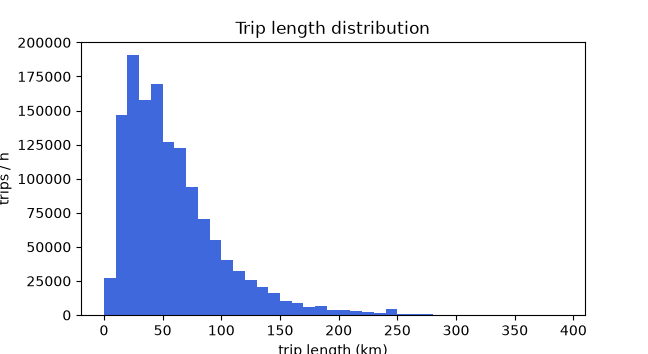

In [51]:
import matplotlib.pyplot as plt

w = T.flatten()
d_km = np.nan_to_num(dist, nan=0).flatten() / 1000
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_km, bins=np.arange(0, 400, 10), weights=w, color="#1d4ed8", alpha=0.85)
ax.set_xlabel("trip length (km)"); ax.set_ylabel("trips / h")
ax.set_title("Trip length distribution")
plt.tight_layout()

## Desire lines

Demand before it meets the network: the biggest district-to-district movements
drawn as straight lines, width scaled by trips.

In [52]:
N = PARAMS["analysis"]["desire_lines_top_n"]
flat = [(i, j, T[i, j]) for i in range(len(T)) for j in range(len(T)) if T[i, j] > 0]
top = sorted(flat, key=lambda x: -x[2])[:N]
cent = by_node.centroid.values
desire = gpd.GeoDataFrame(
    {"from": by_node.name.values[[i for i, j, v in top]],
     "to": by_node.name.values[[j for i, j, v in top]],
     "trips": [round(v) for i, j, v in top]},
    geometry=[LineString([cent[i], cent[j]]) for i, j, v in top], crs=4326)

dmax = float(desire.trips.max())
doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
add_gdf(doc, desire, f"top {N} desire lines",
        symbology=[[field("trips").colormap("plasma", domain=(0.0, dmax)).encoding("stroke"),
                    field("trips").scalar(domain=(0.0, dmax), output_range=(0.5, 8.0)).encoding("stroke-width")]])
doc

## 5. Equilibrium assignment with select link

The full national equilibrium, with a select-link flag on the M6 through
Birmingham so we can afterwards see exactly whose traffic uses it.

In [53]:
from aequilibrae.matrix import AequilibraeMatrix
from aequilibrae.paths import TrafficAssignment, TrafficClass

links_gdf = project.network.links.data
sl_lat, sl_lon = PARAMS["analysis"]["select_link_near"][0], PARAMS["analysis"]["select_link_near"][1]
mways = links_gdf[links_gdf.link_type == "motorway"].copy()
sel_id = int(mways.iloc[(mways.geometry.centroid.distance(gpd.points_from_xy([sl_lon], [sl_lat])[0])).argmin()].link_id)
print(f"select link: motorway link {sel_id} nearest ({sl_lat}, {sl_lon})")

demand = AequilibraeMatrix()
demand.create_empty(zones=graph.num_zones, matrix_names=["matrix"], memory_only=True)
demand.index = graph.centroids[:]
demand.matrices[:, :, 0] = T
demand.computational_view()

AP = PARAMS["assignment"]
car = TrafficClass(name="car", graph=graph, matrix=demand)
car.set_select_links({"m6_birmingham": [(sel_id, 0)]})
assig = TrafficAssignment()
assig.add_class(car)
assig.set_vdf("BPR")
assig.set_vdf_parameters({"alpha": AP["vdf_alpha"], "beta": AP["vdf_beta"]})
assig.set_capacity_field("capacity")
assig.set_time_field("travel_time")
assig.set_algorithm(AP["algorithm"])
assig.max_iter = AP["max_iter"]
assig.rgap_target = AP["rgap"]
t0 = time.perf_counter()
assig.execute()
assig.save_results("peak")
assig.save_select_link_results("m6_analysis")
print(f"equilibrium in {time.perf_counter() - t0:.0f}s")

select link: motorway link 119526 nearest (52.48, -1.89)


car                                               :   0%|          | 0/350 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/30 [00:00<?, ?it/s]

equilibrium in 41s


## Two views of the loaded network

Flow — where the traffic is:

In [54]:
res = assig.results()
loaded = links_gdf.merge(res.reset_index(), on="link_id")
loaded = loaded[(loaded.matrix_tot > PARAMS["analysis"]["flow_display_min"])
                & (loaded.link_type != "centroid_connector")].copy()
loaded["flow"] = loaded.matrix_tot.round(0)
loaded["voc"] = loaded["VOC_max"].clip(upper=1.5).round(3)
loaded["geometry"] = loaded.geometry.simplify(0.004)
fmax = float(loaded.flow.max())

doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
add_gdf(doc, loaded[["link_id", "flow", "geometry"]], "traffic flow (veh/h)",
        symbology=[[field("flow").colormap("YlOrRd", domain=(0.0, fmax)).encoding("stroke"),
                    field("flow").scalar(domain=(0.0, fmax), output_range=(0.5, 7.0)).encoding("stroke-width")]])
doc

Congestion — where the network struggles:

In [55]:
used = loaded[loaded.flow > 0]
print(f"mean V/C {used.VOC_max.mean():.2f}, max {used.VOC_max.max():.2f}, "
      f"{(used.VOC_max > 1).mean() * 100:.1f}% of drawn links over capacity")

doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
add_gdf(doc, loaded[["link_id", "voc", "flow", "geometry"]], "congestion (V/C)",
        symbology=[[field("voc").colormap("RdYlGn", reverse=True, domain=(0.0, 1.5)).encoding("stroke"),
                    field("flow").scalar(domain=(0.0, fmax), output_range=(0.5, 7.0)).encoding("stroke-width")]])
doc

mean V/C 0.48, max 3.31, 7.6% of drawn links over capacity


## Select link: who uses the M6 through Birmingham?

Every link carrying traffic that also crosses the flagged M6 section — the
classic question a select-link analysis answers:

In [56]:
with project.results_connection as conn:
    sl = pd.read_sql("select * from m6_analysis", conn)
if "link_id" not in sl.columns:
    sl = sl.rename(columns={sl.columns[0]: "link_id"})
tot_cols = [c for c in sl.columns if c.endswith("_tot")]
sl["sl_flow"] = sl[tot_cols].sum(axis=1)
sl = sl[sl.sl_flow > 25]
slg = links_gdf.merge(sl[["link_id", "sl_flow"]], on="link_id")
slg["geometry"] = slg.geometry.simplify(0.004)
print(f"{len(slg):,} links carry M6-Birmingham traffic")

doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
add_gdf(doc, slg[["link_id", "sl_flow", "geometry"]], "M6 users",
        symbology=[[field("sl_flow").colormap("Blues", domain=(0.0, float(slg.sl_flow.max()))).encoding("stroke"),
                    field("sl_flow").scalar(domain=(0.0, float(slg.sl_flow.max())), output_range=(0.7, 6.5)).encoding("stroke-width")]])
add_gdf(doc, links_gdf[links_gdf.link_id == sel_id], "the M6 section",
        symbology=[[constant("#dc2626").encoding("stroke"), constant(6.0).encoding("stroke-width")]])
doc

205 links carry M6-Birmingham traffic


## The busiest corridors

In [57]:
loaded["veh_km"] = loaded["matrix_tot"] * loaded["distance"] / 1000
corridors = (loaded[loaded["name"].str.len() > 0].groupby("name")
             .agg(veh_km=("veh_km", "sum"), peak_flow=("matrix_tot", "max"))
             .nlargest(12, "veh_km").round(0).astype(int))
corridors

,veh_km,peak_flow
name,,
M1,3633204,10540
M6,3522856,9553
M4,2653364,9573
M5,2373937,8166
M25,2355745,7871
M62,1584392,9763
A1(M),1517239,6236
A38,1095138,8483
M40,1044205,5487


In [58]:
cor = loaded[loaded["name"].isin(corridors.index)]
doc = new_map(boundary, zoom=6)
add_gdf(doc, boundary, "Great Britain", opacity=0.2, symbology=[[constant("#94a3b8").encoding("fill")]])
add_gdf(doc, merge_lines(loaded, tol=0.01), "network", opacity=0.3,
        symbology=[[constant("#94a3b8").encoding("stroke")]])
add_gdf(doc, cor[["link_id", "name", "flow", "geometry"]], "busiest corridors",
        symbology=[[field("name").categorical("tab20").encoding("stroke"),
                    field("flow").scalar(domain=(0.0, fmax), output_range=(1.2, 6.5)).encoding("stroke-width")]])
doc

## National screenlines

In [59]:
rows = []
for sname, pts in PARAMS["analysis"]["screenlines"].items():
    line = LineString(pts)
    crossing = loaded[loaded.geometry.intersects(line)]
    rows.append({"screenline": sname, "links": len(crossing),
                 "veh_per_hour": round(crossing.matrix_tot.sum())})
pd.DataFrame(rows)

,screenline,links,veh_per_hour
0,England-Scotland border,6,7223
1,England-Wales border,20,23536


## The model on one page

In [60]:
vkt = (loaded.assign(vkm=loaded.matrix_tot * loaded["distance"] / 1000)
       .groupby("link_type").vkm.sum() / 1e6).round(2)
summary = pd.DataFrame({
    "value": [f"{len(roads):,} links / {km_by_cls.sum():,.0f} km",
              f"{len(zones)} districts / {zones.population.sum() / 1e6:.1f}M residents",
              f"{T.sum():,.0f} trips/h",
              f"{np.average(np.nan_to_num(dist, nan=0), weights=T) / 1000:.0f} km",
              f"{used.VOC_max.mean():.2f} mean / {used.VOC_max.max():.2f} max",
              f"{vkt.sum():.1f}M veh-km/h"]},
    index=["network", "zone system", "peak-hour demand", "mean trip length",
           "V/C on drawn links", "vehicle-km travelled"])
print(vkt.rename("million veh-km/h").to_string())
summary

link_type
motorway     28.31
primary       9.93
ramp          1.25
secondary     1.94
trunk        32.70


,value
network,"194,874 links / 94,409 km"
zone system,350 districts / 67.4M residents
peak-hour demand,"1,348,913 trips/h"
mean trip length,59 km
V/C on drawn links,0.48 mean / 3.31 max
vehicle-km travelled,74.1M veh-km/h


## Wrap-up, provenance and licences

One notebook, the whole toolkit: a complete open-data zone system, a
four-class national network built through the consistency triggers,
skims turned into accessibility maps, gravity demand with its trip-length
distribution and desire lines, a converged select-link equilibrium, flow and
congestion views, corridor rankings, national screenlines and a summary page —
with every assumption in one PARAMS cell, ready to be changed.

**Provenance.** Road network © OpenStreetMap contributors (ODbL), Overpass API
extract (motorway/trunk/primary/secondary and ramps, topologically noded,
largest connected component), August 2026. District boundaries: ONS Open
Geography Portal (Open Government Licence v3). Populations: ONS mid-year
estimates via the NOMIS API (OGL v3). GB outline: public-domain world
boundaries.

**Caveats.** Speeds and capacities are class-level defaults; the demand model
is a one-shot gravity calibration against screenline-magnitude anchors, not a
validated forecast; and district-level zones still concentrate urban traffic
onto too few streets inside the largest cities. Every one of those is a PARAMS
change and a re-run away from your own experiments.